In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os
import json
import pandas as pd
import seaborn as sns
import anndata as ad
from scipy.stats import  mannwhitneyu
from sksurv.preprocessing import OneHotEncoder
from lifelines import (CoxPHFitter, KaplanMeierFitter)
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import logrank_test, proportional_hazard_test
import warnings
warnings.filterwarnings("ignore")

In [63]:
extension = 'svg'
save_path = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/myeloma_imc/paper/plots/figures/figure_7/{extension}/'
save_path_supp = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/myeloma_imc/paper/plots/figures/suppl_figure_7/{extension}/'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_standal/results/standard/adatas/cells_final.h5ad")
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/neighborhood_color_map.json', 'r') as f:
    neighborhood_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/phenotype_color_map.json', 'r') as f:
    phenotype_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease_color_map.json', 'r') as f:
    disease_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease3_color_map.json', 'r') as f:
    disease3_color_map = json.load(f)
neighborhood_colors = [neighborhood_color_map[cat] for cat in list(adata.obs['cellcharter_CN'].cat.categories)]
neighborhood_colors = ListedColormap(neighborhood_colors)
phenotype_colors = [phenotype_color_map[cat] for cat in list(adata.obs['Phenotype4'].cat.categories)]
phenotype_colors = ListedColormap(phenotype_colors)
disease_colors = [disease_color_map[cat] for cat in list(adata.obs['disease2'].cat.categories)]
disease_colors = ListedColormap(disease_colors)
disease3_colors = [disease3_color_map[cat] for cat in list(adata.obs['disease3'].cat.categories)]
disease3_colors = ListedColormap(disease3_colors)
pfs_color_map = {'short_PFS': sns.color_palette('dark')[6], 'long_PFS': sns.color_palette('dark')[8]}

In [64]:
md = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/metadata/metadata.csv')
md = md[md['Cohort'].isin(['B', 'UB'])]
md = md.dropna(subset=['Days to progression (PFS)']).reset_index(drop=True)
nbh_enrichment = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_standal/src/downstream/clinical_correlation/nhood_enrichment_patients.csv')
nbh_enrichment.set_index('patient_ID', inplace=True)
nbh_enrichment2 = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_standal/src/downstream/clinical_correlation/immune_COZI_normalized_scores_patients.csv')
nbh_enrichment2.set_index('patient_ID', inplace=True)
nbh_enrichment3 = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_standal/src/downstream/clinical_correlation/nhood_enrichment_images.csv')
nbh_enrichment3.set_index('image_ID', inplace=True)
adata = adata[adata.obs['patient_ID'].isin(md['IMC label'])]
adata.obs['PFS_group'] = adata.obs['patient_ID'].map(md.set_index('IMC label')['Short_long PFS (< or >  2 yrs)'])
adata.obs['PFS_group'] = adata.obs['PFS_group'].astype('category')

In [65]:
nbh_enrichment2.rename(columns={'CD8+Tcells_Plasma Cells/MM cells': 'CD8 T*PCs', 'Plasma Cells/MM cells_CD8+Tcells': 'PCs*CD8 T','Plasma Cells/MM cells_CD4+Tcells': 'PCs*CD4 T',
                                'CD4+Tcells_Plasma Cells/MM cells': 'CD4 T*PCs', 'Plasma Cells/MM cells_Dendritic Cells': 'PCs*DCs', 'Dendritic Cells_Plasma Cells/MM cells': 'DCs*PCs',
                                'Plasma Cells/MM cells_Neutrophils': 'PCs*Neutrophils', 'Neutrophils_Plasma Cells/MM cells': 'Neutrophils*PCs',
                                'Plasma Cells/MM cells_activated Macrophages/Monocytes': 'PCs*HLA-DR+ Macs/monos', 'activated Macrophages/Monocytes_Plasma Cells/MM cells': 'HLA-DR+ Macs/monos*PCs',
                                'Plasma Cells/MM cells_Macrophages/Monocytes': 'PCs*Macs/monos', 'Macrophages/Monocytes_Plasma Cells/MM cells': 'Macs/monos*PCs',
                                'Plasma Cells/MM cells_Plasma Cells/MM cells': 'PCs*PCs'}, inplace=True)
nbh_enrichment.rename(columns={'adaptive_immune*bone_vasculature': 'ADAPTIVE_IMMUNE*BONE_VASCULATURE', 'adaptive_immune*focal_pc_oxphos': 'ADAPTIVE_IMMUNE*PC_OXPHOS',
                                'focal_pc_oxphos*stroma_adipocyte': 'PC_OXPHOS*ADIPOCYTES_PC', 'pc_myeloid*focal_pc_oxphos': 'PC_MYELOID*PC_OXPHOS',
                                'bone_vasculature*focal_pc_oxphos': 'BONE_VASCULATURE*PC_OXPHOS', 'hypoxic_immune*focal_pc_oxphos': 'HIF1A_IMMUNE*PC_OXPHOS'}, inplace=True)

In [66]:
biopsy_pc_fraction = pd.read_excel('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/metadata/percent PCs in biopsies.xlsx')
biopsy_pc_fraction['IMC label'] = biopsy_pc_fraction['IMC label'].astype(str)
biopsy_pc_fraction['IMC label'] = ['IMC' + (x if len(x) >= 2 else '0' + x) for x in biopsy_pc_fraction['IMC label'] if x]
biopsy_pc_fraction.dropna(inplace=True)
md['PC_MYELOID*PC_OXPHOS'] = md['IMC label'].map(nbh_enrichment['PC_MYELOID*PC_OXPHOS'])*10
md['PCs*CD4 T'] = md['IMC label'].map(nbh_enrichment2['PCs*CD4 T'])*10
md['CD8 T*PCs'] = md['IMC label'].map(nbh_enrichment2['CD8 T*PCs'])*10
md['HLA-DR+ Macs/monos*PCs'] = md['IMC label'].map(nbh_enrichment2['HLA-DR+ Macs/monos*PCs'])*10
md['ADAPTIVE_IMMUNE*PC_OXPHOS'] = md['IMC label'].map(nbh_enrichment['ADAPTIVE_IMMUNE*PC_OXPHOS'])*10
md['biopsy_PC_fraction'] = md['IMC label'].map(biopsy_pc_fraction.set_index('IMC label')['% PCs from biopsy'])

In [67]:
md

,IMC label,Cohort,Gender,Age time of diagnosis,Event (Progress) occurred,Days to progression (PFS),PFS from first time of diagnosis until relapse (days),Event (Death) occurred,OS (days),Short_long PFS (< or > 2 yrs),...,>=3 lesions,>=5 lesions,>=10 lesions,Days to progression from noBD/SMM to BD,PC_MYELOID*PC_OXPHOS,PCs*CD4 T,CD8 T*PCs,HLA-DR+ Macs/monos*PCs,ADAPTIVE_IMMUNE*PC_OXPHOS,biopsy_PC_fraction
0,IMC01,UB,Male,67.0,True,1766.0,3424.0,True,3313.0,long_PFS,...,False,False,False,NaN,0.573700,0.421207,0.259899,0.369306,0.603781,10.0
1,IMC07,UB,Male,66.0,True,1448.0,1766.0,True,2891.0,long_PFS,...,True,False,False,1858.0,1.586357,0.184823,-0.712576,-0.028371,-0.874054,95.0
2,IMC08,B,Female,65.0,True,833.0,4050.0,True,3733.0,long_PFS,...,False,False,False,NaN,1.753984,0.888849,-0.222941,-0.412395,-0.597045,55.0
3,IMC09,B,Male,58.0,True,1337.0,1337.0,True,2062.0,long_PFS,...,False,True,False,NaN,0.198029,0.511363,0.328676,0.264025,0.169969,10.0
4,IMC12,UB,Female,79.0,True,258.0,258.0,True,1370.0,short_PFS,...,False,False,False,1235.0,1.045386,0.891683,0.066120,0.361441,0.507116,65.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,IMC90.1,B,Female,58.0,True,1536.0,1536.0,False,3418.0,long_PFS,...,False,False,False,NaN,0.188512,0.897453,0.017767,0.235693,-0.328402,45.0
59,IMC92,B,Female,54.0,False,6033.0,NaN,False,6033.0,long_PFS,...,True,False,False,NaN,0.591141,0.478542,0.472081,0.751342,0.116658,9.9
60,IMC93,B,Female,71.0,True,2375.0,2375.0,True,3954.0,long_PFS,...,False,False,True,NaN,0.677594,0.511499,0.183141,0.370500,0.323863,50.0
61,IMC95,B,Female,58.0,True,1966.0,1966.0,True,4847.0,long_PFS,...,False,True,False,NaN,0.544465,-0.000592,0.247649,0.041851,0.068558,8.0


In [68]:
treat = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/metadata/treatment_metadata.csv')
treat

,IMC ID,long or short,PFS time,ASCT (yes/no),IMiDs based (yes/no),VCD (yes/no),Treatment line full information
0,IMC01,long_PFS,1766.0,False,True,False,"Revlimid, Dexamethason"
1,IMC07,long_PFS,1448.0,False,True,False,"Alkeran, Prednisolon, Revlimid"
2,IMC08,long_PFS,833.0,False,True,False,"Melfalan, Prednisolon, Thalidomid"
3,IMC09,long_PFS,1337.0,True,False,True,Radiation therapy (Melfalan i 2013)
4,IMC12,short_PFS,258.0,False,False,True,"Bortezomib, Cyklofosfamid, Dexametason (VCD)"
...,...,...,...,...,...,...,...
58,IMC90.1,long_PFS,1536.0,True,False,True,"Bortezomib, Cyklofosfamid, Dexametason (VCD)"
59,IMC92,long_PFS,6033.0,True,False,True,"Cyklofosfamid, Dexametason (Cd)"
60,IMC93,long_PFS,2375.0,False,True,False,"Melfalan, Thalidomid, Prednisolon (MTp)"
61,IMC95,long_PFS,1966.0,True,False,True,"Bortezomib, Cyklofosfamid, Dexametason (VCD)"


In [69]:
md = pd.merge(md, treat, left_on='IMC label', right_on='IMC ID', how='left')
md.drop(columns=['IMC ID', 'long or short', 'PFS time'], inplace=True)
md['ASCT (yes/no)'] = md['ASCT (yes/no)'].astype('boolean')

In [70]:
md.to_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/metadata/metadata_extended.csv', index=False)

In [32]:
md.columns

Index(['IMC label', 'Cohort', 'Gender', 'Age time of diagnosis',
       'Event (Progress) occurred', 'Days to progression (PFS)',
       'PFS from first time of diagnosis until relapse (days)',
       'Event (Death) occurred', 'OS (days)', 'Short_long PFS (< or >  2 yrs)',
       'BMI', 'FISH/(translocations/del)', 'R-ISS', 'Treatment line 1',
       'Bone disease upon time of diagnosis/biopsy',
       'Bone disease later in disease course', 'Compression fractures ',
       'Fractures ossis  longi or ossis plani', '>= 1 lesion', '>=3 lesions',
       '>=5 lesions', '>=10 lesions',
       'Days to progression from noBD/SMM to BD', 'PC_MYELOID*PC_OXPHOS',
       'PCs*CD4 T', 'CD8 T*PCs', 'HLA-DR+ Macs/monos*PCs',
       'ADAPTIVE_IMMUNE*PC_OXPHOS', 'biopsy_PC_fraction', 'PFS time',
       'ASCT (yes/no)', 'IMiDs based (yes/no)', 'VCD (yes/no)',
       'Treatment line full information'],
      dtype='object')

# CoxPH with ASCT patients

## Without R-ISS

In [71]:
md_cox = md.drop(columns=['IMC label', 'Cohort', 'BMI', 'FISH/(translocations/del)','Treatment line 1', 'Days to progression from noBD/SMM to BD', 
                              'PFS from first time of diagnosis until relapse (days)', 'Short_long PFS (< or >  2 yrs)', 'Event (Death) occurred', 
                              'OS (days)', 'Fractures ossis  longi or ossis plani', '>= 1 lesion', '>=3 lesions', '>=5 lesions', '>=10 lesions', 'Bone disease later in disease course',
                              #'Gender', 'Age time of diagnosis', 
                              'Compression fractures ', 'R-ISS',
                              'Bone disease upon time of diagnosis/biopsy',
                              ])

In [72]:
md_cox = md_cox[md_cox['ASCT (yes/no)'] == True]
md_cox = md_cox.drop(columns=['ASCT (yes/no)', 'IMiDs based (yes/no)', 'VCD (yes/no)' , 'Treatment line full information'])
md_cox.head()

,Gender,Age time of diagnosis,Event (Progress) occurred,Days to progression (PFS),PC_MYELOID*PC_OXPHOS,PCs*CD4 T,CD8 T*PCs,HLA-DR+ Macs/monos*PCs,ADAPTIVE_IMMUNE*PC_OXPHOS,biopsy_PC_fraction
3,Male,58.0,True,1337.0,0.198029,0.511363,0.328676,0.264025,0.169969,10.0
8,Male,61.0,True,894.0,-2.701047,0.424011,-0.628295,0.241096,-1.359114,90.0
11,Male,61.0,True,843.0,0.370075,0.289529,0.194650,0.369797,0.386837,10.0
12,Male,60.0,True,188.0,0.871427,1.461971,0.526823,1.160034,0.383995,50.0
13,Female,58.0,True,286.0,0.944521,0.296738,0.320995,0.197305,0.910524,70.0


In [73]:
md_cox

,Gender,Age time of diagnosis,Event (Progress) occurred,Days to progression (PFS),PC_MYELOID*PC_OXPHOS,PCs*CD4 T,CD8 T*PCs,HLA-DR+ Macs/monos*PCs,ADAPTIVE_IMMUNE*PC_OXPHOS,biopsy_PC_fraction
3,Male,58.0,True,1337.0,0.198029,0.511363,0.328676,0.264025,0.169969,10.0
8,Male,61.0,True,894.0,-2.701047,0.424011,-0.628295,0.241096,-1.359114,90.0
11,Male,61.0,True,843.0,0.370075,0.289529,0.194650,0.369797,0.386837,10.0
12,Male,60.0,True,188.0,0.871427,1.461971,0.526823,1.160034,0.383995,50.0
13,Female,58.0,True,286.0,0.944521,0.296738,0.320995,0.197305,0.910524,70.0
14,Female,52.0,True,306.0,1.423007,0.351620,-1.114400,-0.468252,-1.959262,90.0
17,Male,70.0,True,1469.0,0.064247,0.597752,0.225952,0.460702,2.061248,60.0
18,Male,55.0,True,674.0,0.100089,0.570519,1.897224,1.067310,2.266582,20.0
19,Male,60.0,True,686.0,0.530977,0.687726,0.908019,0.570268,1.130521,20.0
23,Male,45.0,True,381.0,0.500575,0.443095,0.548158,0.842241,-0.730835,50.0


In [74]:
md_pfs = md_cox.dropna().reset_index(drop=True)
arr_3 = np.array(md_pfs['Days to progression (PFS)'])
arr_pfs_numeric = np.empty(len(arr_3), dtype=[('Status', '?'), ('PFS_in_days', '<f8')])
for i, e in enumerate(arr_3):
    if md_pfs['Event (Progress) occurred'][i] == False:
        arr_pfs_numeric[i] = (False, e)
    else:
        arr_pfs_numeric[i] = (True, e)
cat_cols = md_pfs.select_dtypes(include=['object']).columns
md_pfs[cat_cols] = md_pfs[cat_cols].astype('category')
md_pfs_numeric = OneHotEncoder().fit_transform(md_pfs)
md_pfs_numeric

,Gender=Male,Age time of diagnosis,Event (Progress) occurred,Days to progression (PFS),PC_MYELOID*PC_OXPHOS,PCs*CD4 T,CD8 T*PCs,HLA-DR+ Macs/monos*PCs,ADAPTIVE_IMMUNE*PC_OXPHOS,biopsy_PC_fraction
0,1.0,58.0,True,1337.0,0.198029,0.511363,0.328676,0.264025,0.169969,10.0
1,1.0,61.0,True,894.0,-2.701047,0.424011,-0.628295,0.241096,-1.359114,90.0
2,1.0,61.0,True,843.0,0.370075,0.289529,0.194650,0.369797,0.386837,10.0
3,1.0,60.0,True,188.0,0.871427,1.461971,0.526823,1.160034,0.383995,50.0
4,0.0,58.0,True,286.0,0.944521,0.296738,0.320995,0.197305,0.910524,70.0
5,0.0,52.0,True,306.0,1.423007,0.351620,-1.114400,-0.468252,-1.959262,90.0
6,1.0,70.0,True,1469.0,0.064247,0.597752,0.225952,0.460702,2.061248,60.0
7,1.0,55.0,True,674.0,0.100089,0.570519,1.897224,1.067310,2.266582,20.0
8,1.0,60.0,True,686.0,0.530977,0.687726,0.908019,0.570268,1.130521,20.0
9,1.0,45.0,True,381.0,0.500575,0.443095,0.548158,0.842241,-0.730835,50.0


In [75]:
cph = CoxPHFitter(penalizer=0.01, l1_ratio=0.5)
cph.fit(md_pfs_numeric, duration_col = 'Days to progression (PFS)', event_col = 'Event (Progress) occurred')

<lifelines.CoxPHFitter: fitted with 38 total observations, 10 right-censored observations>

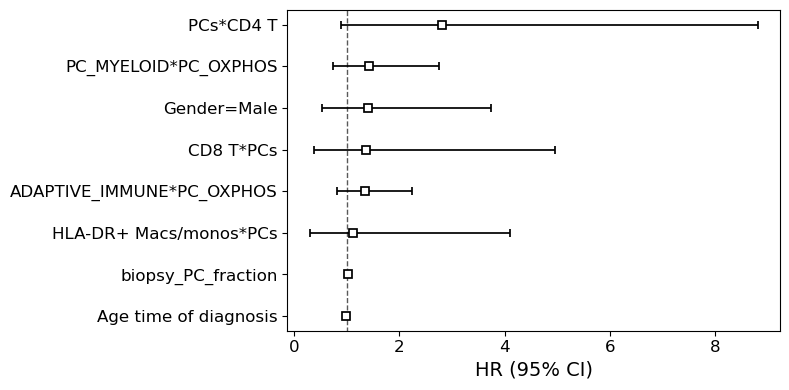

In [76]:
fig, ax = plt.subplots(figsize=(8, 4))
cph.plot(ax=ax, hazard_ratios=True)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
fig.tight_layout()
#fig.savefig(os.path.join(save_path, f"coxph_pfs_all_scaled_biopsy_pc_riss_combined.{extension}"), bbox_inches='tight')

## With R-ISS

In [77]:
md_cox = md.drop(columns=['IMC label', 'Cohort', 'BMI', 'FISH/(translocations/del)','Treatment line 1', 'Days to progression from noBD/SMM to BD', 
                              'PFS from first time of diagnosis until relapse (days)', 'Short_long PFS (< or >  2 yrs)', 'Event (Death) occurred', 
                              'OS (days)', 'Fractures ossis  longi or ossis plani', '>= 1 lesion', '>=3 lesions', '>=5 lesions', '>=10 lesions', 'Bone disease later in disease course',
                              #'Gender', 'Age time of diagnosis', 
                              'Compression fractures ',
                              'Bone disease upon time of diagnosis/biopsy',
                              ])

In [78]:
md_cox = md_cox[md_cox['ASCT (yes/no)'] == True]
md_cox = md_cox.drop(columns=['ASCT (yes/no)', 'IMiDs based (yes/no)', 'VCD (yes/no)' , 'Treatment line full information'])
md_cox['R-ISS'] = md_cox['R-ISS'].replace({'II': 'II/III', 'III': 'II/III'})
md_cox.head()

,Gender,Age time of diagnosis,Event (Progress) occurred,Days to progression (PFS),R-ISS,PC_MYELOID*PC_OXPHOS,PCs*CD4 T,CD8 T*PCs,HLA-DR+ Macs/monos*PCs,ADAPTIVE_IMMUNE*PC_OXPHOS,biopsy_PC_fraction
3,Male,58.0,True,1337.0,NaN,0.198029,0.511363,0.328676,0.264025,0.169969,10.0
8,Male,61.0,True,894.0,II/III,-2.701047,0.424011,-0.628295,0.241096,-1.359114,90.0
11,Male,61.0,True,843.0,II/III,0.370075,0.289529,0.194650,0.369797,0.386837,10.0
12,Male,60.0,True,188.0,II/III,0.871427,1.461971,0.526823,1.160034,0.383995,50.0
13,Female,58.0,True,286.0,II/III,0.944521,0.296738,0.320995,0.197305,0.910524,70.0


In [79]:
md_pfs = md_cox.dropna().reset_index(drop=True)
arr_3 = np.array(md_pfs['Days to progression (PFS)'])
arr_pfs_numeric = np.empty(len(arr_3), dtype=[('Status', '?'), ('PFS_in_days', '<f8')])
for i, e in enumerate(arr_3):
    if md_pfs['Event (Progress) occurred'][i] == False:
        arr_pfs_numeric[i] = (False, e)
    else:
        arr_pfs_numeric[i] = (True, e)
cat_cols = md_pfs.select_dtypes(include=['object']).columns
md_pfs[cat_cols] = md_pfs[cat_cols].astype('category')
md_pfs_numeric = OneHotEncoder().fit_transform(md_pfs)
md_pfs_numeric

,Gender=Male,Age time of diagnosis,Event (Progress) occurred,Days to progression (PFS),R-ISS=II/III,PC_MYELOID*PC_OXPHOS,PCs*CD4 T,CD8 T*PCs,HLA-DR+ Macs/monos*PCs,ADAPTIVE_IMMUNE*PC_OXPHOS,biopsy_PC_fraction
0,1.0,61.0,True,894.0,1.0,-2.701047,0.424011,-0.628295,0.241096,-1.359114,90.0
1,1.0,61.0,True,843.0,1.0,0.370075,0.289529,0.194650,0.369797,0.386837,10.0
2,1.0,60.0,True,188.0,1.0,0.871427,1.461971,0.526823,1.160034,0.383995,50.0
3,0.0,58.0,True,286.0,1.0,0.944521,0.296738,0.320995,0.197305,0.910524,70.0
4,0.0,52.0,True,306.0,1.0,1.423007,0.351620,-1.114400,-0.468252,-1.959262,90.0
5,1.0,70.0,True,1469.0,1.0,0.064247,0.597752,0.225952,0.460702,2.061248,60.0
6,1.0,45.0,True,381.0,0.0,0.500575,0.443095,0.548158,0.842241,-0.730835,50.0
7,0.0,59.0,True,791.0,1.0,-0.852857,0.998359,-0.410606,-0.339787,-1.710784,55.0
8,1.0,65.0,True,619.0,0.0,0.525571,1.165282,0.602497,0.871924,1.242044,10.0
9,1.0,61.0,False,1979.0,0.0,-1.288993,0.307313,-0.092659,-0.811341,-0.508994,30.0


In [80]:
cph = CoxPHFitter(penalizer=0.01, l1_ratio=0.5)
cph.fit(md_pfs_numeric, duration_col = 'Days to progression (PFS)', event_col = 'Event (Progress) occurred')

<lifelines.CoxPHFitter: fitted with 33 total observations, 9 right-censored observations>

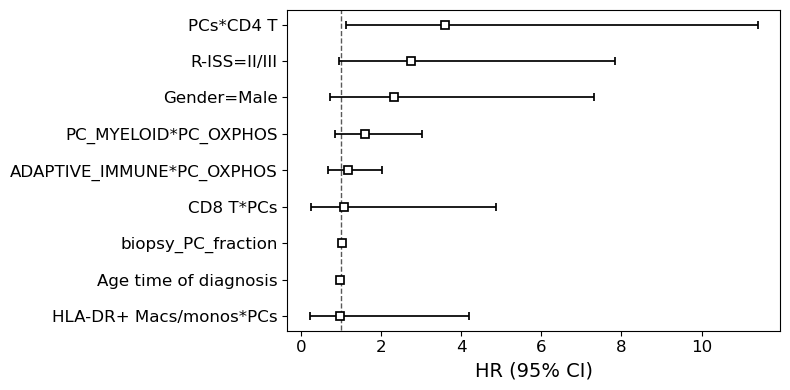

In [81]:
fig, ax = plt.subplots(figsize=(8, 4))
cph.plot(ax=ax, hazard_ratios=True)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
fig.tight_layout()
#fig.savefig(os.path.join(save_path, f"coxph_pfs_all_scaled_biopsy_pc_riss_combined.{extension}"), bbox_inches='tight')

# Integrating treatment into the general CoxPH model

## Without R-ISS

In [82]:
md_cox = md.drop(columns=['IMC label', 'Cohort', 'BMI', 'FISH/(translocations/del)','Treatment line 1', 'Days to progression from noBD/SMM to BD', 
                              'PFS from first time of diagnosis until relapse (days)', 'Short_long PFS (< or >  2 yrs)', 'Event (Death) occurred', 
                              'OS (days)', 'Fractures ossis  longi or ossis plani', '>= 1 lesion', '>=3 lesions', '>=5 lesions', '>=10 lesions', 'Bone disease later in disease course',
                              #'Gender', 'Age time of diagnosis', 
                              'Compression fractures ', 'R-ISS', 'Treatment line full information',
                              'Bone disease upon time of diagnosis/biopsy',
                              ])

In [83]:
md_pfs = md_cox.dropna().reset_index(drop=True)
arr_3 = np.array(md_pfs['Days to progression (PFS)'])
arr_pfs_numeric = np.empty(len(arr_3), dtype=[('Status', '?'), ('PFS_in_days', '<f8')])
for i, e in enumerate(arr_3):
    if md_pfs['Event (Progress) occurred'][i] == False:
        arr_pfs_numeric[i] = (False, e)
    else:
        arr_pfs_numeric[i] = (True, e)
cat_cols = md_pfs.select_dtypes(include=['object']).columns
md_pfs[cat_cols] = md_pfs[cat_cols].astype('category')
md_pfs_numeric = OneHotEncoder().fit_transform(md_pfs)
cph = CoxPHFitter(penalizer=0.01, l1_ratio=0.5)
cph.fit(md_pfs_numeric, duration_col = 'Days to progression (PFS)', event_col = 'Event (Progress) occurred')

<lifelines.CoxPHFitter: fitted with 62 total observations, 11 right-censored observations>

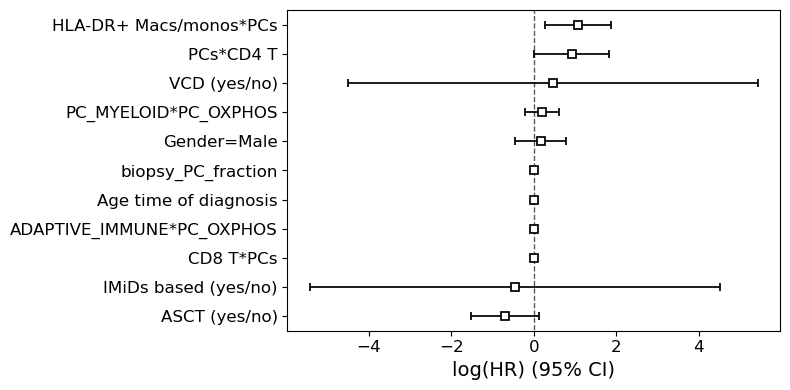

In [84]:
fig, ax = plt.subplots(figsize=(8, 4))
cph.plot(ax=ax)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
fig.tight_layout()
#fig.savefig(os.path.join(save_path, f"coxph_pfs_all_scaled_biopsy_pc_riss_combined.{extension}"), bbox_inches='tight')

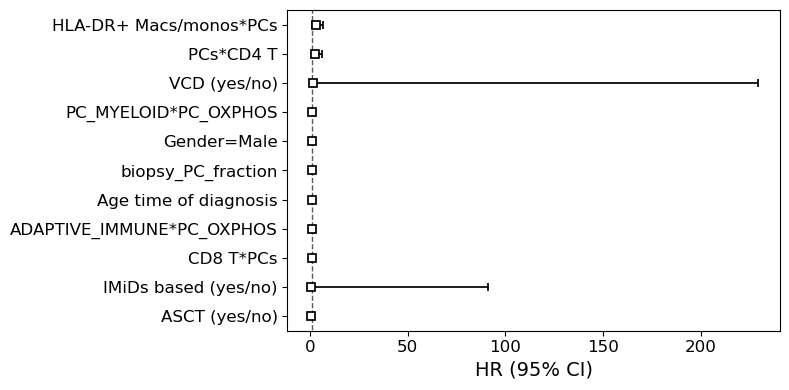

In [85]:
fig, ax = plt.subplots(figsize=(8, 4))
cph.plot(ax=ax, hazard_ratios=True)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
fig.tight_layout()
#fig.savefig(os.path.join(save_path, f"coxph_pfs_all_scaled_biopsy_pc_riss_combined.{extension}"), bbox_inches='tight')

## With R-ISS

In [86]:
md_cox = md.drop(columns=['IMC label', 'Cohort', 'BMI', 'FISH/(translocations/del)','Treatment line 1', 'Days to progression from noBD/SMM to BD', 
                              'PFS from first time of diagnosis until relapse (days)', 'Short_long PFS (< or >  2 yrs)', 'Event (Death) occurred', 
                              'OS (days)', 'Fractures ossis  longi or ossis plani', '>= 1 lesion', '>=3 lesions', '>=5 lesions', '>=10 lesions', 'Bone disease later in disease course',
                              #'Gender', 'Age time of diagnosis', 
                              'Compression fractures ', 'Treatment line full information',
                              'Bone disease upon time of diagnosis/biopsy',
                              ])

In [87]:
md.dtypes

IMC label                                                 object
Cohort                                                    object
Gender                                                    object
Age time of diagnosis                                    float64
Event (Progress) occurred                                   bool
Days to progression (PFS)                                float64
PFS from first time of diagnosis until relapse (days)    float64
Event (Death) occurred                                      bool
OS (days)                                                float64
Short_long PFS (< or >  2 yrs)                            object
BMI                                                      float64
FISH/(translocations/del)                                 object
R-ISS                                                     object
Treatment line 1                                          object
Bone disease upon time of diagnosis/biopsy                  bool
Bone disease later in dis

In [88]:
md_pfs_numeric.dtypes

Gender=Male                  float64
Age time of diagnosis        float64
Event (Progress) occurred       bool
Days to progression (PFS)    float64
PC_MYELOID*PC_OXPHOS         float64
PCs*CD4 T                    float64
CD8 T*PCs                    float64
HLA-DR+ Macs/monos*PCs       float64
ADAPTIVE_IMMUNE*PC_OXPHOS    float64
biopsy_PC_fraction           float64
ASCT (yes/no)                boolean
IMiDs based (yes/no)            bool
VCD (yes/no)                    bool
dtype: object

In [89]:
md_cox['R-ISS'] = md_cox['R-ISS'].replace({'II': 'II/III', 'III': 'II/III'})
md_pfs = md_cox.dropna().reset_index(drop=True)
arr_3 = np.array(md_pfs['Days to progression (PFS)'])
arr_pfs_numeric = np.empty(len(arr_3), dtype=[('Status', '?'), ('PFS_in_days', '<f8')])
for i, e in enumerate(arr_3):
    if md_pfs['Event (Progress) occurred'][i] == False:
        arr_pfs_numeric[i] = (False, e)
    else:
        arr_pfs_numeric[i] = (True, e)
cat_cols = md_pfs.select_dtypes(include=['object']).columns
md_pfs[cat_cols] = md_pfs[cat_cols].astype('category')
md_pfs_numeric = OneHotEncoder().fit_transform(md_pfs)
cph = CoxPHFitter(penalizer=0.01, l1_ratio=0.5)
cph.fit(md_pfs_numeric, duration_col = 'Days to progression (PFS)', event_col = 'Event (Progress) occurred')

<lifelines.CoxPHFitter: fitted with 49 total observations, 10 right-censored observations>

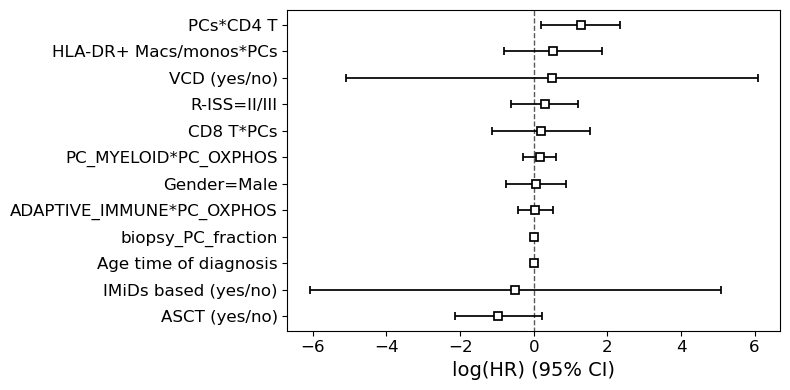

In [90]:
fig, ax = plt.subplots(figsize=(8, 4))
cph.plot(ax=ax)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
fig.tight_layout()
#fig.savefig(os.path.join(save_path, f"coxph_pfs_all_scaled_biopsy_pc_riss_combined.{extension}"), bbox_inches='tight')

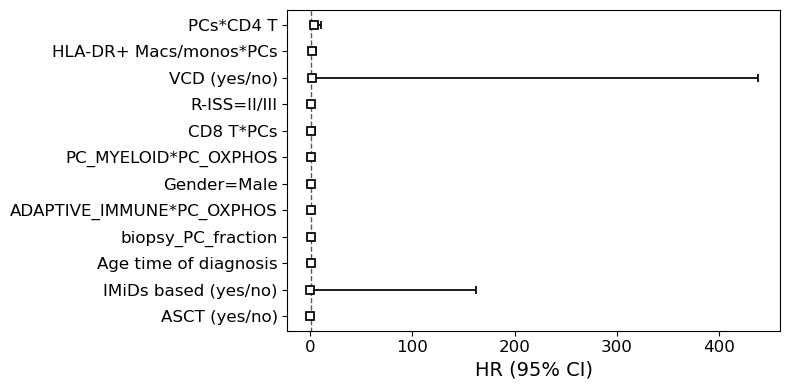

In [91]:
fig, ax = plt.subplots(figsize=(8, 4))
cph.plot(ax=ax, hazard_ratios=True)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
fig.tight_layout()
#fig.savefig(os.path.join(save_path, f"coxph_pfs_all_scaled_biopsy_pc_riss_combined.{extension}"), bbox_inches='tight')